In [135]:
import numpy as np
import scienceplots
import matplotlib.pyplot as plt
# initialize
#u0 = 1.682*10**-21 #Joules
#r0 = 3.86*10**-10 #meters
#k=1.38*10**-23 #Joules / Kelvin

#u0 = 0.0105 #eV
#r0 = 3.86 #Angstroms
#k = 8.617*10**-5 #Joules / Kelvin
u0=1
r0=1


In [96]:
def LJ(r):
        value = u0 * (((r0/r)**12)-(2*((r0/r)**6)))
        return value

In [26]:
def Simpson(T,a,b,num_points):
    def function(r,T):
        value = (r**2) *LJ(r)*np.exp(LJ(r)/(k*T))
        return value
    dr = (b-a)/num_points
    integral = function(a,T)
    for i in range(1,num_points,2):
        integral += 4*function(a+(i*dr),T)
    for i in range(2,num_points-2,2):
        integral += 2*function(a+(i*dr),T)
    integral += function(b,T)
    integral *= (dr/3)
    return integral

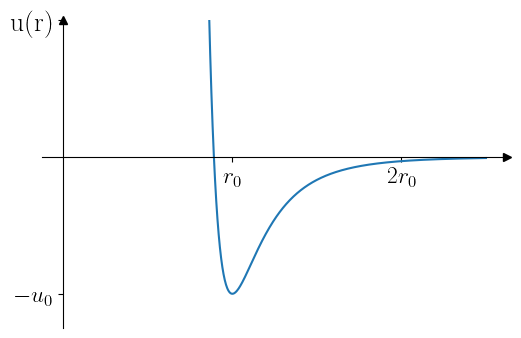

In [207]:
r = np.linspace(0.1*r0,2.5*r0,1000)
pot = LJ(r)
#plt.yscale('log')
#plt.style.use('science')
plt.style.use('default')
plt.figure(figsize=(6,4))
plt.plot(r,pot)
plt.ylim(-1.25,1)
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 17
})
ax = plt.gca()
ax.spines[['left','bottom']].set_position(('data',0))
ax.spines[['top','right']].set_visible(False)
ax.plot(1,0,">k",transform=ax.get_yaxis_transform(),clip_on=False)
ax.plot(0,1*u0,"^k",transform=ax.get_xaxis_transform(),clip_on=False)

#plt.xlabel("hello")
ax.get_yticklabels()[0].set_fontsize(20)
ax.get_yticklabels()[0].set_fontstyle('italic')
plt.xticks((1,2),[r"$r_0$",r"$2r_0$"])
plt.yticks((1,-u0),[r"u(r)",r"$-u_0$"])

#plt.tick_params(top=False,right=False)

plt.show()